Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from plotnine import *
from utils import *

#### Config

In [2]:
#### Discount Rates and Spreads ####
yields_df = pd.read_csv('data/rates.csv', usecols = ['date', 'yield'], parse_dates=['date'], dayfirst=True)
rates = Rates(data=yields_df)

# Spreads
spread_map = {"A": 0.02, "BBB": 0.03, "BB": 0.04, "B": 0.05, "CCC": 0.06}


#### Liabilities ####
liabilities_df = pd.read_csv('data/liabs.csv', usecols = ['date', 'cashflow'], parse_dates=['date'], dayfirst=True)
liabilities = Liabilities(data = liabilities_df)


#### Bonds and Issuers ####
# Issuers
issuers_df = data = pd.read_csv('data/issuers_hvb.csv', dtype={'id': 'str'}, usecols=['id', 'sector', 'rating'])
issuers = Issuers(issuers_df)

# HVB Bonds
hvb_bond_data = pd.read_csv('data/bonds_hvb.csv', usecols = ['id','issuer_id','notional','recovery'], dtype={'id': 'str', 'issuer_id': 'str'})
hvb_cashflows = pd.read_csv('data/cashflows_hvb.csv', parse_dates=['date'], date_format='%Y/%m').set_index('date')
hvb_cashflow_table = hvb_cashflows.resample('YE').sum().reset_index()

bonds = Bonds(
    data = hvb_bond_data,
    cashflow_table=hvb_cashflow_table,
    issuers=issuers
)


#### Credit Risk Model ####
# Economy and Sector correlations
rho_e = .1
rho_s = np.array([.2, .3])

# Transition matrix
rating_labels = ['A', 'BBB', 'BB', 'B', 'CCC', 'Default']
transition_matrix = TransitionMatrix(
    tmatrix = np.array([
    [0.85, 0.05, 0.04, 0.03, 0.02, 0.01],
    [0.05, 0.81, 0.05, 0.04, 0.03, 0.02],
    [0.00, 0.05, 0.83, 0.05, 0.04, 0.03],
    [0.00, 0.00, 0.05, 0.86, 0.05, 0.04],
    [0.00, 0.00, 0.00, 0.05, 0.90, 0.05],
    [0.00, 0.00, 0.00, 0.00, 0.00, 1.00]
    ]),
    labels = rating_labels
)

# Model
cr_model = CreditRiskModel(
    issuers = issuers,
    rho_e = rho_e,
    rho_s = rho_s,
    transition_matrix = transition_matrix
)

#### CDI Mandate ####
val_date = pd.to_datetime('28-02-2025', dayfirst = True)
gaap_int = 0.0201
mortality_buffer = 12.8078e06
asset_buffer = np.array([
    12.5e06, 12_987_500, 13_494_013, 14_020_279, 14_567_070, 15_135_186,
    15_725_458, 16_338_751, 16_975_962, 17_638_024, 18_325_907, 18e06
])

# Asset Protfolio
portfolio = Portfolio(
    asset_list = [bonds],
    allocations = [400e06]
)
cash = 0

# CDI Portfolio
cdi_fox = CDIMandate_Fox(
    liabilities=liabilities,
    portfolio=portfolio,
    cash=cash,
    asset_buffer=asset_buffer,
    gaap_int=gaap_int,
    mortality_buffer=mortality_buffer
)

### Run Simulation

In [3]:
np.random.seed(42)
n_sim = 250
n_years = 65

sim_results = cr_model.run(n_sim=n_sim, n_years=n_years)
cdi_sim_results = cdi_fox.run(val_date, rates, spread_map, sim_results)

### Plots

Expected Value of Payment: 0.0


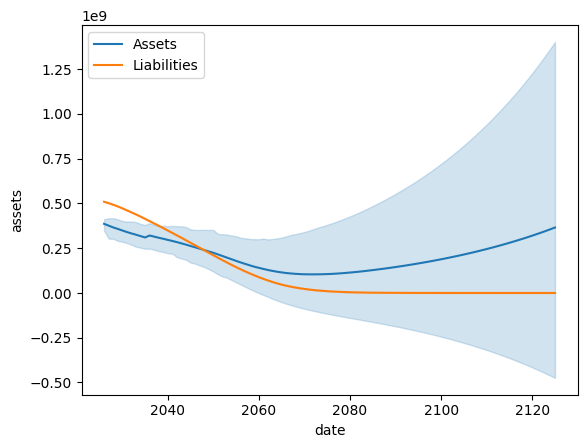

In [8]:
print(f"Expected Value of Payment: {cdi_sim_results.expected_pv_payment}")
sns.lineplot(data=cdi_sim_results.cdi_results, x = 'date', y = 'assets', errorbar = ('pi', 100), label = 'Assets')
sns.lineplot(data=cdi_sim_results.cdi_results, x = 'date', y = 'liability_pvs', label = 'Liabilities');